In [1]:
# how to uncover truths that don't matter - second section

# basic script to load in two datasets, merging them together, and ensure dtypes in dataframe

# loading libraries already for later use
import numpy as np

import matplotlib.pyplot as plt 
import seaborn as sns

import pandas as pd

# loading dataframes
fdf = pd.read_csv("data/flights_sample_3m.csv")
ldf = pd.read_csv("data/airports.csv")

# Define time columns
time_columns = ["ARR_TIME", "DEP_TIME", "WHEELS_OFF", "WHEELS_ON", "CRS_ARR_TIME", "CRS_DEP_TIME"]

# defining a helper function
def convert_time(df, time_columns):
    """ Convert integer time columns to HH:MM format """
    for col in time_columns:
        # Handle missing values and convert times
        df[col] = df[col].fillna(0).astype(int).apply(lambda x: f"{x//100:02d}:{x%100:02d}")
        # Adjust for hours == 24
        df[col] = df[col].replace("24:00", "00:00")
    return df

# convert to datetime
fdf["FL_DATE"] = pd.to_datetime(fdf["FL_DATE"])

# Apply the time conversion
fdf = convert_time(fdf, time_columns)

# Combine dates and times into datetime
fdf["arr_datetime"] = pd.to_datetime(fdf["FL_DATE"].astype(str) + " " + fdf["ARR_TIME"])
fdf["dep_datetime"] = pd.to_datetime(fdf["FL_DATE"].astype(str) + " " + fdf["DEP_TIME"])

fdf["crs_arr_datetime"] = pd.to_datetime(fdf["FL_DATE"].astype(str) + " " + fdf["CRS_ARR_TIME"])
fdf["crs_dep_datetime"] = pd.to_datetime(fdf["FL_DATE"].astype(str) + " " + fdf["CRS_DEP_TIME"])

fdf["woff_datetime"] = pd.to_datetime(fdf["FL_DATE"].astype(str) + " " + fdf["WHEELS_OFF"])
fdf["won_datetime"] = pd.to_datetime(fdf["FL_DATE"].astype(str) + " " + fdf["WHEELS_ON"])

# Drop original time columns
fdf = fdf.drop(time_columns, axis=1)

# setting up boolean columns
boolean_columns = ["CANCELLED", "DIVERTED"]
fdf[boolean_columns] = fdf[boolean_columns].astype("bool")

# setting up categorical columns
categorical = ["ORIGIN", "DEST", "ORIGIN_CITY", "DEST_CITY", "AIRLINE", "AIRLINE_DOT", "AIRLINE_CODE", "CANCELLATION_CODE"] 
fdf[categorical] = fdf[categorical].astype("category")

# setting up merge
# Check unique values in both datasets
fdf_airports = set(fdf["ORIGIN"].unique()).union(set(fdf["DEST"].unique()))
ldf_airports = set(ldf["IATA"].unique())  # "IATA" is the column with the airport acronyms

# Find missing airport codes in ldf
missing_airports = fdf_airports.difference(ldf_airports)

# Drop rows where "ORIGIN" or "DEST" are in missing_airports
fdf_cleaned = fdf[~fdf["ORIGIN"].isin(missing_airports) & ~fdf["DEST"].isin(missing_airports)]

# Merge fdf with ldf to add geographical data for ORIGIN and DEST
fdf_merged = pd.merge(fdf_cleaned, ldf[["IATA", "LATITUDE", "LONGITUDE"]], 
                      left_on="ORIGIN", right_on="IATA", how="left")
fdf_merged = pd.merge(fdf_merged, ldf[["IATA", "LATITUDE", "LONGITUDE"]], 
                      left_on="DEST", right_on="IATA", how="left", suffixes=("_ORIGIN", "_DEST"))

# Drop original origin and destination columns
fdf_merged = fdf_merged.drop(["ORIGIN", "DEST"], axis=1)

# enforcing categories on newly generated columns
fdf_merged[["IATA_ORIGIN", "IATA_DEST"]] = fdf_merged[["IATA_ORIGIN", "IATA_DEST"]].astype("category")

# checking dtypes of columns to doublecheck if everything worked as intended
print(fdf_merged.dtypes)

FL_DATE                    datetime64[ns]
AIRLINE                          category
AIRLINE_DOT                      category
AIRLINE_CODE                     category
DOT_CODE                            int64
FL_NUMBER                           int64
ORIGIN_CITY                      category
DEST_CITY                        category
DEP_DELAY                         float64
TAXI_OUT                          float64
TAXI_IN                           float64
ARR_DELAY                         float64
CANCELLED                            bool
CANCELLATION_CODE                category
DIVERTED                             bool
CRS_ELAPSED_TIME                  float64
ELAPSED_TIME                      float64
AIR_TIME                          float64
DISTANCE                          float64
DELAY_DUE_CARRIER                 float64
DELAY_DUE_WEATHER                 float64
DELAY_DUE_NAS                     float64
DELAY_DUE_SECURITY                float64
DELAY_DUE_LATE_AIRCRAFT           

In [2]:
# import selfbuild module
import coriolis_module

In [3]:
# check out if everything is as expected
print(dir(coriolis_module))

['__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'direction_vector']


In [4]:
# import some functions
import coriolis_functions 

In [5]:
# check out if everything is as expected
print(dir(coriolis_functions))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'calculate_total_drift', 'coriolis_acc', 'coriolis_integral', 'haversine', 'main', 'np', 'radius_at_latitude', 'rotation_matrix']


In [6]:
# calculating haversinedistance
fdf_merged['haversine_distance'] = coriolis_functions.haversine(
    fdf_merged["LATITUDE_ORIGIN"],
    fdf_merged["LONGITUDE_ORIGIN"],
    fdf_merged["LATITUDE_DEST"], 
    fdf_merged["LONGITUDE_DEST"]
)

In [7]:
# Apply direction vector function row-wise
directions = fdf_merged.apply(
    lambda row: coriolis_module.direction_vector(
        row["LATITUDE_ORIGIN"], 
        row["LONGITUDE_ORIGIN"], 
        row["LATITUDE_DEST"], 
        row["LONGITUDE_DEST"]
    ), axis=1
)

# Split the resulting direction vectors into separate columns
fdf_merged["x_direction"] = directions.apply(lambda x: x[0])
fdf_merged["y_direction"] = directions.apply(lambda x: x[1])
fdf_merged["z_direction"] = directions.apply(lambda x: x[2])

In [8]:
# Apply the calculate_total_drift function row by row
fdf_merged["total_drift_distance"] = fdf_merged.apply(
    lambda row: coriolis_functions.calculate_total_drift(
        row, row["AIR_TIME"] * 60, num_steps=100  # adjust num_steps for precision
    ), axis=1
)

In [9]:
# taking only the not cancelled flights
fdf = fdf_merged[~fdf_merged["CANCELLED"]]

In [10]:
# division of drift through distance gives percentage
fdf.loc[:, "drift_factor"] = fdf["total_drift_distance"] / fdf["haversine_distance"].replace(0, pd.NA)

/tmp/ipykernel_22521/697045568.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fdf.loc[:, "drift_factor"] = fdf["total_drift_distance"] / fdf["haversine_distance"].replace(0, pd.NA)


In [11]:
# checking out the absolut drift distance
fdf["total_drift_distance"].describe()

count    2.863927e+06
mean     3.780473e+02
std      6.672241e+02
min      4.007331e-02
25%      3.953415e+01
50%      1.225282e+02
75%      3.722912e+02
max      1.233596e+04
Name: total_drift_distance, dtype: float64

In [12]:
# taking a look at how much percentage the drift actually is in comparison to distance
fdf["drift_factor"].describe()

count    2.863927e+06
mean     1.819271e-01
std      1.652114e-01
min      3.723836e-04
25%      6.558233e-02
50%      1.241624e-01
75%      2.472431e-01
max      1.506786e+00
Name: drift_factor, dtype: float64

In [13]:
# because we did a lot, let's take another look at dtypes
fdf.dtypes

FL_DATE                    datetime64[ns]
AIRLINE                          category
AIRLINE_DOT                      category
AIRLINE_CODE                     category
DOT_CODE                            int64
FL_NUMBER                           int64
ORIGIN_CITY                      category
DEST_CITY                        category
DEP_DELAY                         float64
TAXI_OUT                          float64
TAXI_IN                           float64
ARR_DELAY                         float64
CANCELLED                            bool
CANCELLATION_CODE                category
DIVERTED                             bool
CRS_ELAPSED_TIME                  float64
ELAPSED_TIME                      float64
AIR_TIME                          float64
DISTANCE                          float64
DELAY_DUE_CARRIER                 float64
DELAY_DUE_WEATHER                 float64
DELAY_DUE_NAS                     float64
DELAY_DUE_SECURITY                float64
DELAY_DUE_LATE_AIRCRAFT           

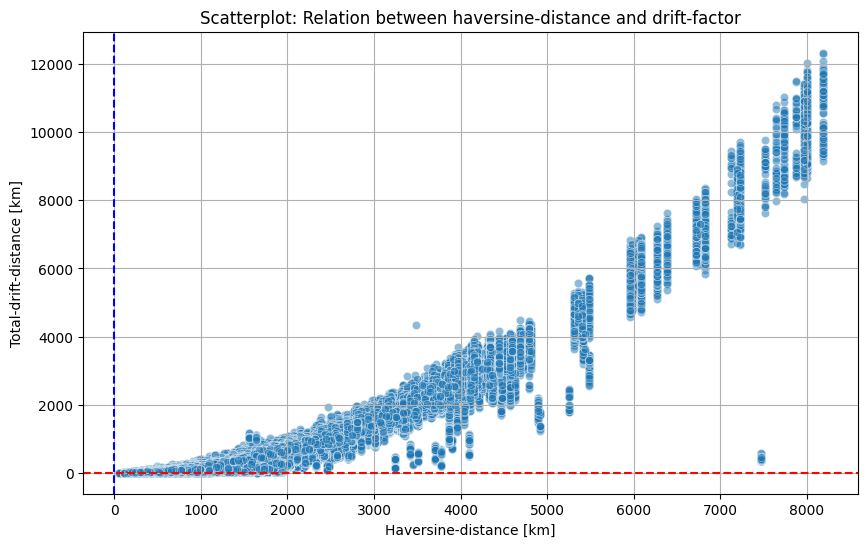

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="haversine_distance", y="total_drift_distance", data=fdf, alpha=0.5)
plt.title("Scatterplot: Relation between haversine-distance and drift-factor")
plt.xlabel("Haversine-distance [km]")
plt.ylabel("Total-drift-distance [km]")
plt.axhline(0, color="red", linestyle="--")  # Reference line for on-time arrivals
plt.axvline(0, color="blue", linestyle="--")  # Reference line for on-time departures
plt.grid(True)
plt.show()

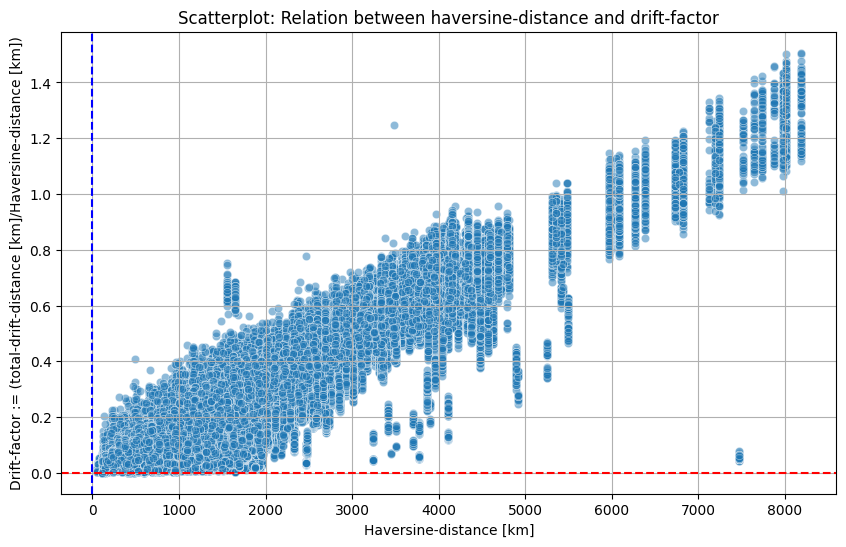

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="haversine_distance", y="drift_factor", data=fdf, alpha=0.5)
plt.title("Scatterplot: Relation between haversine-distance and drift-factor")
plt.xlabel("Haversine-distance [km]")
plt.ylabel("Drift-factor := (total-drift-distance [km]/Haversine-distance [km])")
plt.axhline(0, color="red", linestyle="--")  # Reference line for on-time arrivals
plt.axvline(0, color="blue", linestyle="--")  # Reference line for on-time departures
plt.grid(True)
plt.show()

In [16]:
# sidenotes:  
# haversine-distance := flight-trajectory-length
# drift-factor := (total-drift-distance/haversine-distance) 
# drift-factor seems to have a linear relation to the total-disance
# possible continuation: 
# - linear regression and statistics-evaluation of standard-deviation. 

Text(0.5, 1.0, 'Boxplot of distances')

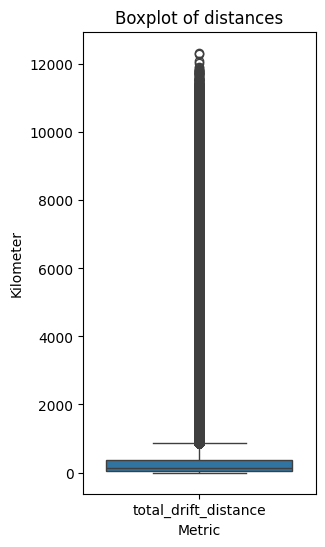

In [17]:
# setting up the boxplots

# prepairing data for boxplots to take a view about outliers when it comes to drift-distances
melted_data = fdf_merged.melt(value_vars=["total_drift_distance"], var_name="Metric", value_name="Kilometer")

# plotting
plt.figure(figsize=(3,6))
sns.boxplot(x="Metric", y="Kilometer", data=melted_data, legend=False)
plt.title("Boxplot of distances")

In [18]:
# how much is this coriolis-drift in absolute numbers? 
absolute_drift_distance = fdf["total_drift_distance"].sum()

# lets compare that somehow to the distances used for calculations
absolute_travel_distance = fdf["haversine_distance"].sum()

# since we assume haversine_distance >= total_drift_distance 
interim_results_dict = {
     "total drift distance [km]" : f"{absolute_drift_distance:.2f}",
    "total traveled distance by non cancelled flights [km]" : f"{absolute_travel_distance:.2f}",
    "average-drift-factor": f"{(absolute_drift_distance / absolute_travel_distance):.4f}",
    "%-value of average-coriolis-drift in dataframe": f"{ (absolute_drift_distance / absolute_travel_distance)*100:.2f}"
}

for name in interim_results_dict:
    print(f"{interim_results_dict[name]} : {name}")

1082699784.38 : total drift distance [km]
3758590035.77 : total traveled distance by non cancelled flights [km]
0.2881 : average-drift-factor
28.81 : %-value of average-coriolis-drift in dataframe


In [19]:
# Intermedium result:
# "All not-cancelled flights in the dataframe drift by 29% 
# in relation to their the flight-trajectory-length because of the earths rotation."

In [20]:
# rename columns to match the original
fdf.rename(columns={"IATA_ORIGIN": "ORIGIN", 'IATA_DEST': "DEST"}, inplace=True)

/tmp/ipykernel_22521/2031736777.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fdf.rename(columns={"IATA_ORIGIN": "ORIGIN", 'IATA_DEST': "DEST"}, inplace=True)


In [21]:
# drop redundand columns before saving the results
fdf = fdf.drop(["CANCELLED", "LATITUDE_ORIGIN", "LONGITUDE_ORIGIN", "LATITUDE_DEST", "LONGITUDE_DEST", "x_direction", "y_direction", "z_direction", "drift_factor"], axis=1)

In [22]:
# save dataframe to new .csv file 
fdf.to_csv("data/not_cancelled_flights.csv")